<a href="https://colab.research.google.com/github/suryansh24-coder/Machine-Learning-Journey/blob/main/FeatureScaling_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("wine_data.csv" , header=None , usecols=[0,1,2])
df.columns=['Class label','Alcohol','Malic acid']

In [3]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

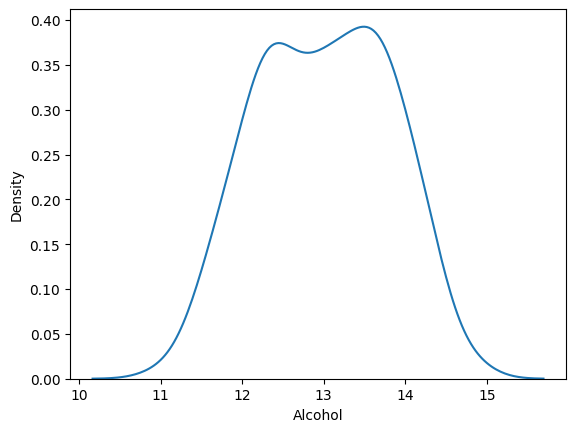

In [4]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

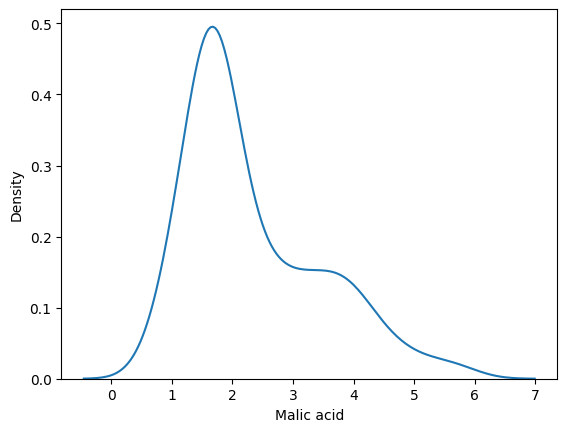

In [7]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

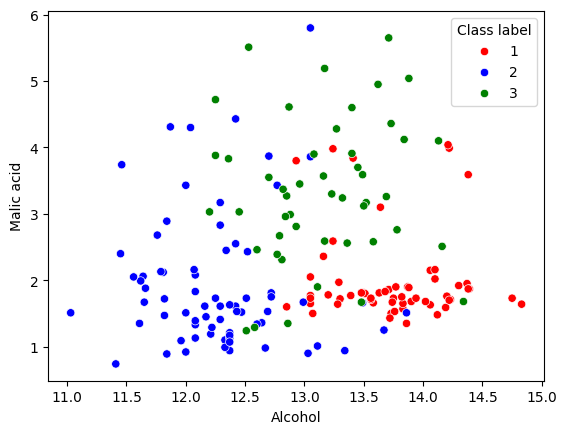

In [9]:
color_dict={1:'red' , 3:'green' , 2:'blue'}
sns.scatterplot(x=df['Alcohol'] ,y=df['Malic acid'],hue=df['Class label'] ,palette=color_dict)

In [10]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train ,y_test = train_test_split(df.drop('Class label', axis = 1) ,
                                                      df['Class label'],
                                                      test_size=0.3,
                                                      random_state=0)
X_train.shape , X_test.shape

((124, 2), (54, 2))

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [12]:
x_test_scaled = pd.DataFrame(x_test_scaled)
x_train_scaled = pd.DataFrame(x_train_scaled)

In [13]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [15]:
np.round(x_train_scaled.describe(),1)

,0,1
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


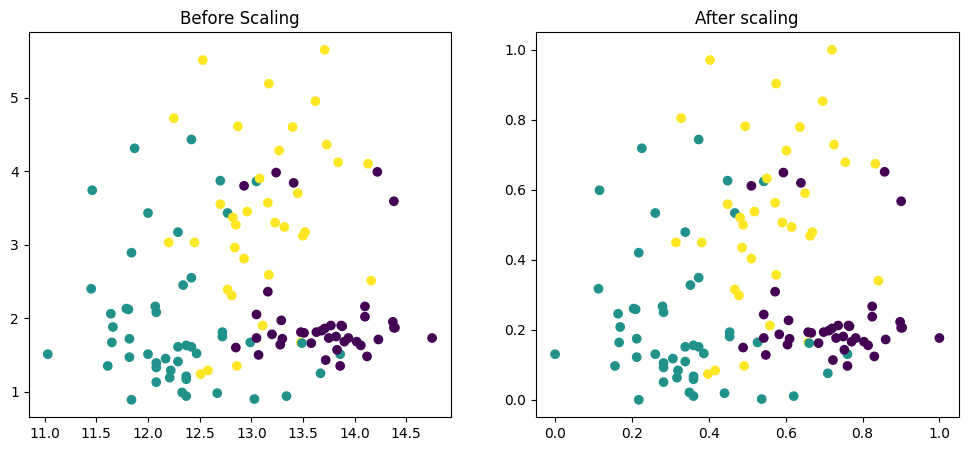

In [17]:
fig , (ax1 ,ax2) = plt.subplots(ncols=2 , figsize =(12,5))

ax1.scatter(X_train['Alcohol'] , X_train['Malic acid'] , c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled[0] , x_train_scaled[1] , c=y_train)
ax2.set_title("After scaling")
plt.show()

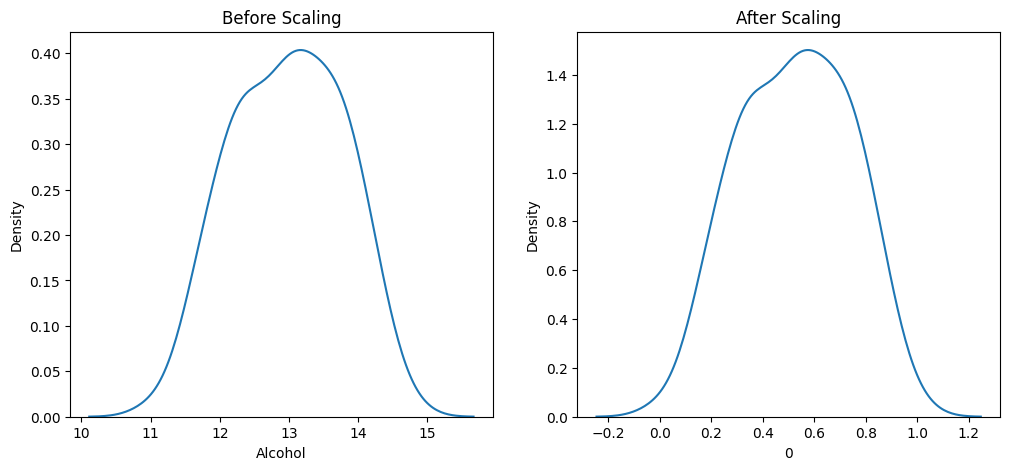

In [23]:
fig ,(ax1 ,ax2) = plt.subplots(ncols=2 , figsize=(12,5))
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'] , ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled[0] , ax=ax2)

plt.show()

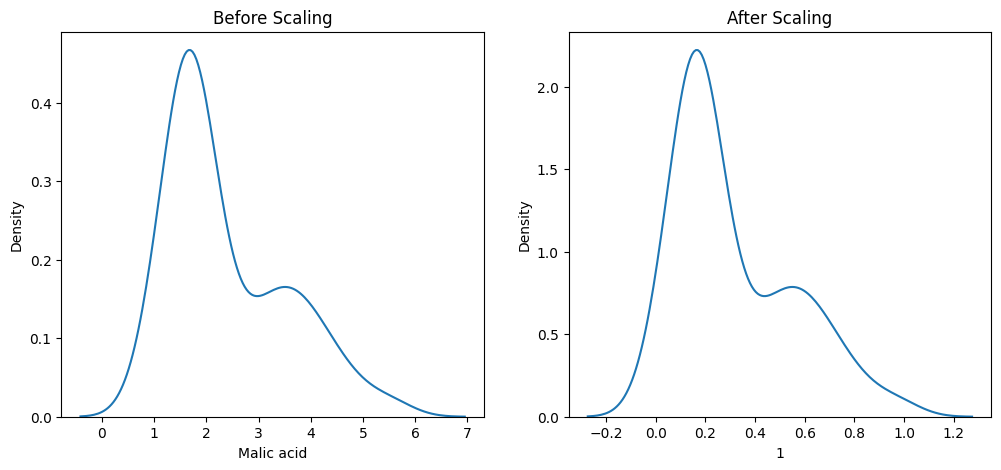

In [24]:
fig ,(ax1 ,ax2) = plt.subplots(ncols=2 , figsize=(12,5))
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Malic acid'] , ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled[1] , ax=ax2)
plt.show()

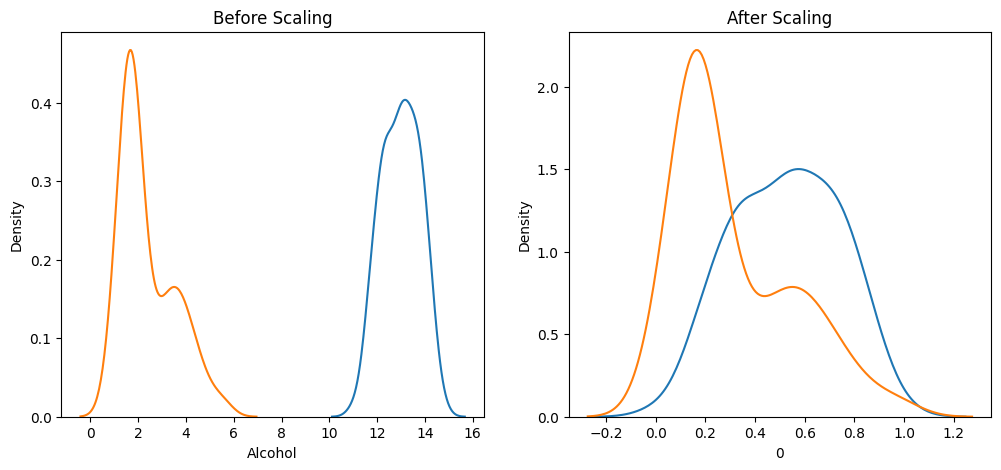

In [22]:
fig ,(ax1 ,ax2) = plt.subplots(ncols=2 , figsize=(12,5))
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'] , ax=ax1)
sns.kdeplot(X_train['Malic acid'] , ax=ax1)
ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled[0] , ax=ax2)
sns.kdeplot(x_train_scaled[1] , ax=ax2)
plt.show()